In [1]:


import numpy as np
import matplotlib.pyplot as plt
import matplotlib as mpl
mpl.rcParams.update({"axes.grid":False})



In [2]:
from ContactMechanics import PeriodicFFTElasticHalfSpace, FreeFFTElasticHalfSpace
from SurfaceTopography import Topography, UniformLineScan
from ContactMechanics.Factory import make_system

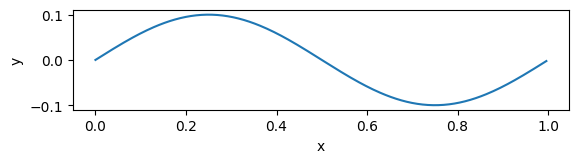

In [ ]:


nx = 256
sx = 1 




x = np.arange(nx) * sx / nx
h = 0.1  * np.sin(2* np.pi * x) 

topography = UniformLineScan(h, physical_sizes=sx, periodic=True)

fig, ax = plt.subplots()
ax.plot(*topography.positions_and_heights())

ax.set_xlabel("x")
ax.set_ylabel("y")
ax.set_aspect(1)

Es =1 
substrate = PeriodicFFTElasticHalfSpace(nb_grid_pts=nx, young=Es, physical_sizes = sx)

Text(0, 0.5, 'A_{real} / A_{nominal}')

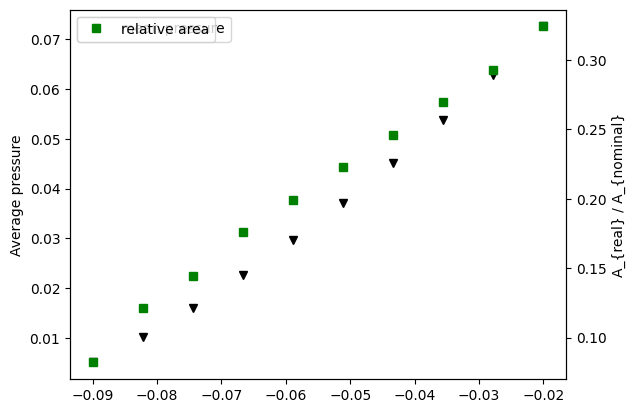

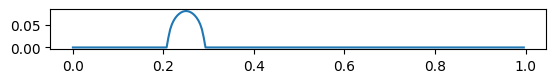

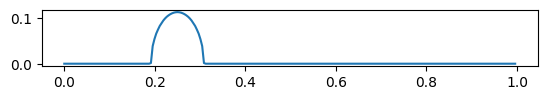

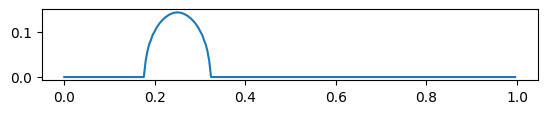

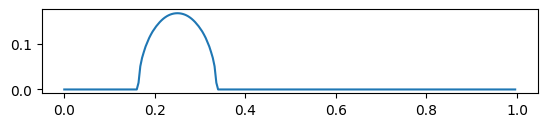

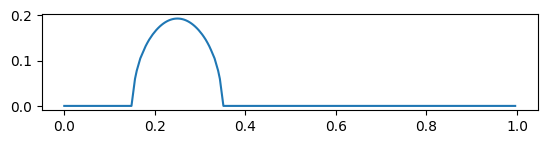

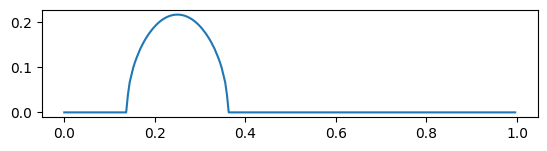

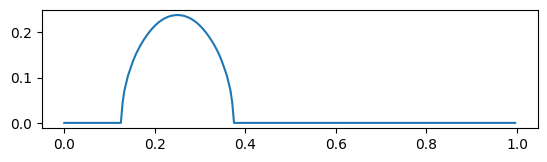

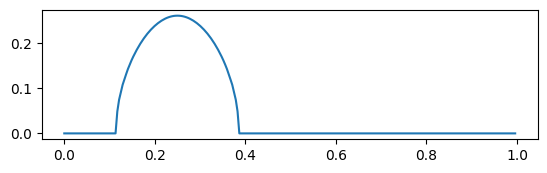

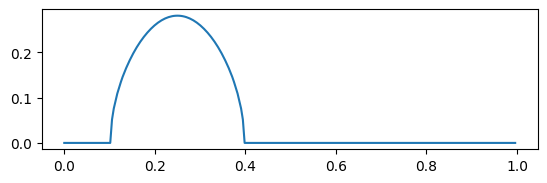

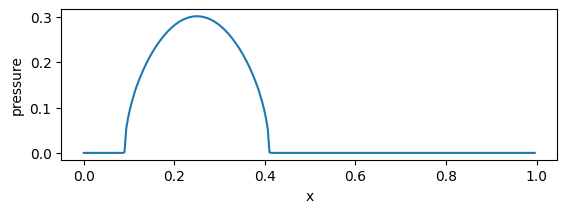

In [5]:
system = make_system(substrate=substrate, surface=topography)

fig, ax = plt.subplots()
axa = ax.twinx()

disps0 = None # you don't have a 

init_force = np.zeros(substrate.nb_grid_pts)
solver='ccg-without-restart'

gtol = 1e-4 * topography.rms_height_from_profile() # I think that the gradient is the gap between the sirfaces

for offset in np.linspace(-0.9,-0.2,10) * 0.1 :
    sol = system.minimize_proxy(offset=offset, initial_displacements = disps0, pentol= 1e-9, maxiter = 100000)

    sol = system.dual_minimize_proxy(
            offset=offset,
            init_force=init_force,
            solver=solver,
            gtol=gtol
            #logger=screen
            )
    
    init_force = sol.x
    assert sol.success, "{}".format(sol)

    lf, = ax.plot(offset, system.compute_normal_force() / (sx ), "vk")
    la, = axa.plot(offset, system.compute_contact_area() / (sx), "sg")
    
    figc,axc=plt.subplots()
    axc.plot(x, system.force / system.area_per_pt)

    axc.set_aspect(1)

axc.set_xlabel("x")
axc.set_ylabel("pressure")

lf.set_label("mean pressure")
la.set_label("relative area")
axa.legend()
ax.legend()
ax.set_ylabel("Average pressure")
axa.set_ylabel("A_{real} / A_{nominal}")

